In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visulaization
%matplotlib inline
sns.set(style="whitegrid")

In [ ]:
file_path = "/content/Data.csv"
df = pd.read_csv(file_path)
df.head()

,Unnamed: 0,Type_of_cement,Brand,Additives,Type_of_aggregates,Design_F'c (Mpa),Curing_age_(days),Cs_(Mpa),Ts_(Mpa),Fs_(Mpa),Er_(ohm-cm),UPV_(m/s)
0,0,CPO 30R RS BRA,CEMEX,Opuntia_ficus_indica,Rounded,25,3,5.2154,0.5609,NaN,5.8654,2440.2989
1,1,CPO 30R RS BRA,CEMEX,Opuntia_ficus_indica,Rounded,25,3,5.1528,0.5727,NaN,5.9471,2417.9562
2,2,CPO 30R RS BRA,CEMEX,Opuntia_ficus_indica,Rounded,25,3,5.6877,0.5826,NaN,5.9965,2429.9277
3,3,CPO 30R RS BRA,CEMEX,Opuntia_ficus_indica,Rounded,25,3,5.1476,0.5910,NaN,5.8751,2435.0202
4,4,CPO 30R RS BRA,CEMEX,Opuntia_ficus_indica,Rounded,25,3,5.3406,0.5698,NaN,5.8654,2408.7969


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4420 entries, 0 to 4419
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          4420 non-null   int64  
 1   Type_of_cement      4420 non-null   object 
 2   Brand               4420 non-null   object 
 3   Additives           4420 non-null   object 
 4   Type_of_aggregates  4420 non-null   object 
 5   Design_F'c (Mpa)    4420 non-null   int64  
 6   Curing_age_(days)   4420 non-null   int64  
 7   Cs_(Mpa)            4420 non-null   float64
 8   Ts_(Mpa)            3460 non-null   float64
 9   Fs_(Mpa)            1760 non-null   float64
 10  Er_(ohm-cm)         4420 non-null   float64
 11  UPV_(m/s)           4420 non-null   float64
dtypes: float64(5), int64(3), object(4)
memory usage: 414.5+ KB


,Unnamed: 0,Design_F'c (Mpa),Curing_age_(days),Cs_(Mpa),Ts_(Mpa),Fs_(Mpa),Er_(ohm-cm),UPV_(m/s)
count,4420.000000,4420.000000,4420.000000,4420.000000,3460.000000,1760.000000,4420.000000,4420.000000
mean,2209.500000,28.959276,40.443439,31.193113,2.481807,3.421582,6.760444,3808.959267
std,1276.088424,3.509038,33.308785,9.588822,0.875311,2.369809,2.970590,561.041125
min,0.000000,25.000000,3.000000,5.082300,0.531100,0.336700,1.831200,2345.981200
25%,1104.750000,25.000000,14.000000,24.962400,2.051875,1.171900,4.639225,3364.670525
50%,2209.500000,28.000000,28.000000,31.853700,2.358400,3.138100,6.070350,3722.880700
75%,3314.250000,30.000000,60.000000,36.075400,2.941725,5.564500,7.461300,4357.101400
max,4419.000000,35.000000,120.000000,55.709200,5.272000,8.086900,16.169300,4666.354800


In [ ]:
# Remove columns 'Ts_(Mpa)' and 'Fs_(Mpa)'
df_2 = df.drop(['Ts_(Mpa)', 'Fs_(Mpa)','Unnamed: 0','Type_of_cement',	'Brand',	'Additives',	'Type_of_aggregates'], axis=1)
df_2.head()

,Design_F'c (Mpa),Curing_age_(days),Cs_(Mpa),Er_(ohm-cm),UPV_(m/s)
0,25,3,5.2154,5.8654,2440.2989
1,25,3,5.1528,5.9471,2417.9562
2,25,3,5.6877,5.9965,2429.9277
3,25,3,5.1476,5.8751,2435.0202
4,25,3,5.3406,5.8654,2408.7969


In [ ]:
print(set(df['Type_of_aggregates']))

{'Recycled ', 'Volcanic', 'Crushed', 'Rounded'}


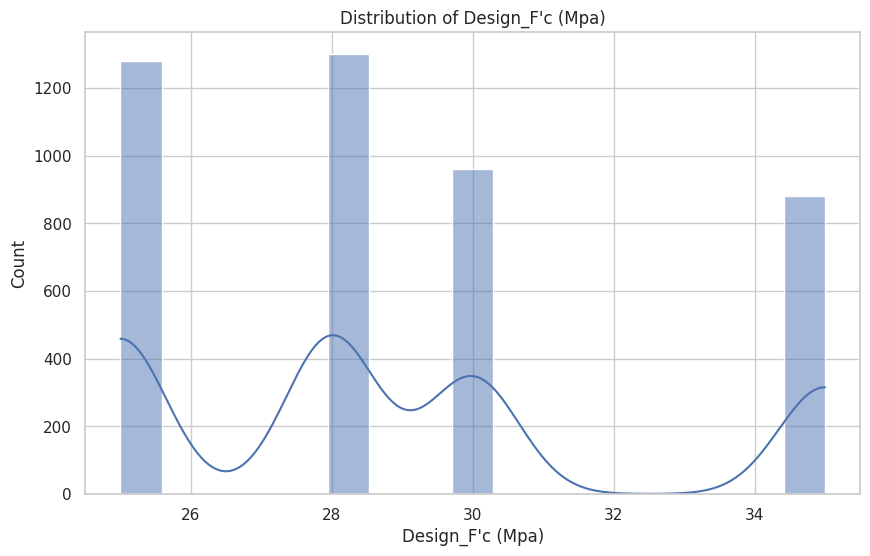

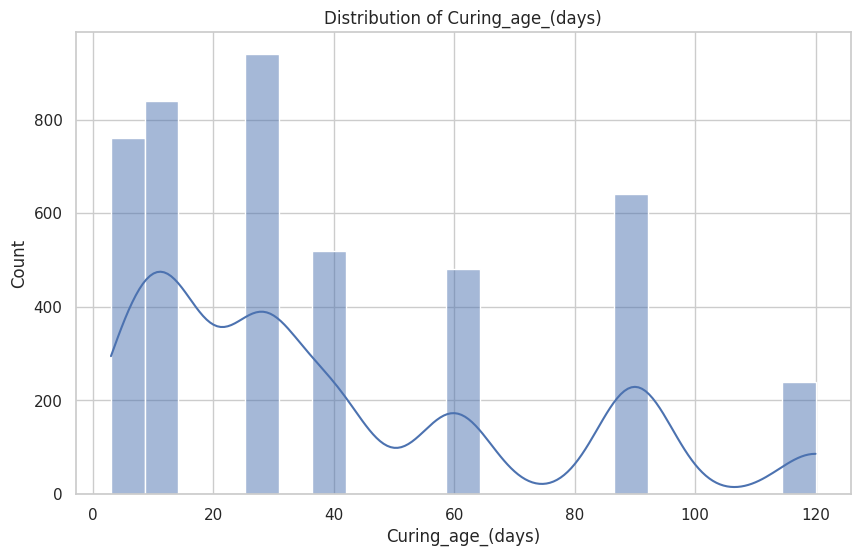

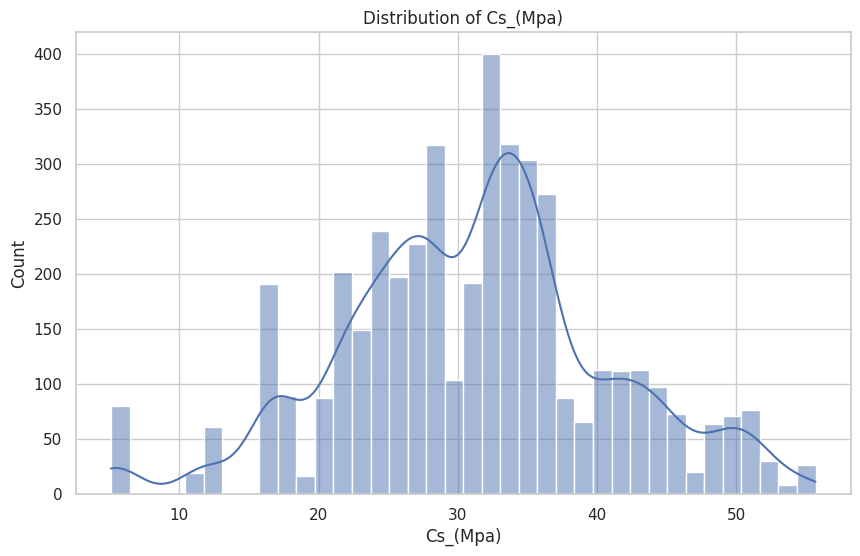

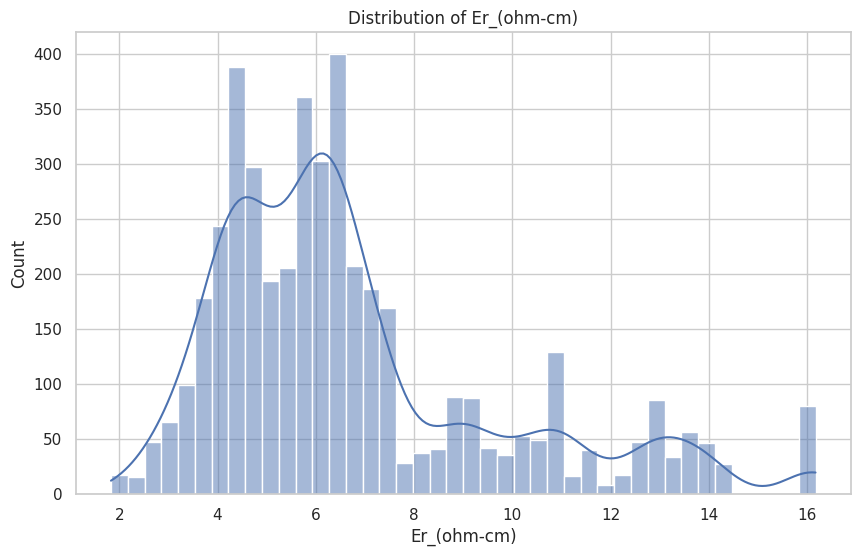

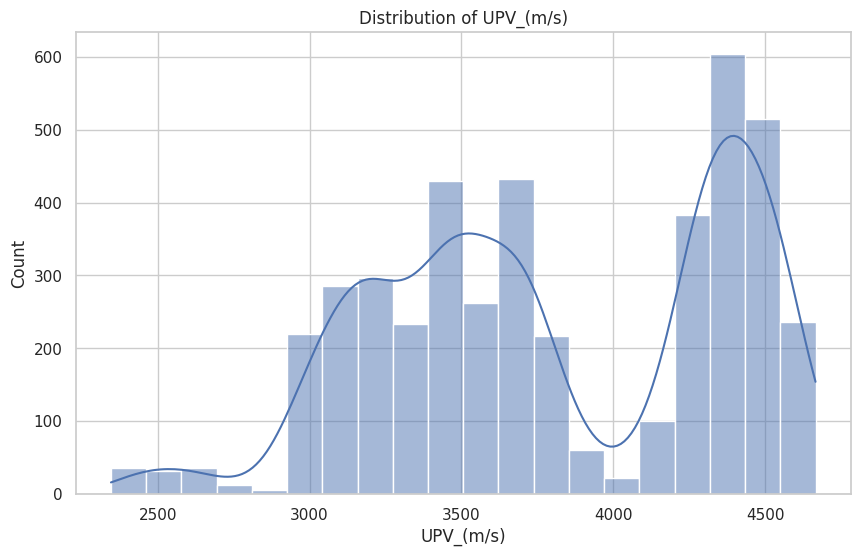

In [ ]:
numercial_features_0 = ['Curing_age_(days)','Er_(ohm-cm)','UPV_(m/s)','Cs_(Mpa)']
numerical_features = df_2.select_dtypes(include=[np.number])
numerical_features.columns

for feature in numerical_features.columns:
  if feature in df.columns:
    plt.figure(figsize=(10,6))
    sns.histplot(df[feature], kde=True)
    plt.title(f'Distribution of {feature}')
    plt.show()
  else:
    print(f'{feature} not in dataframe')

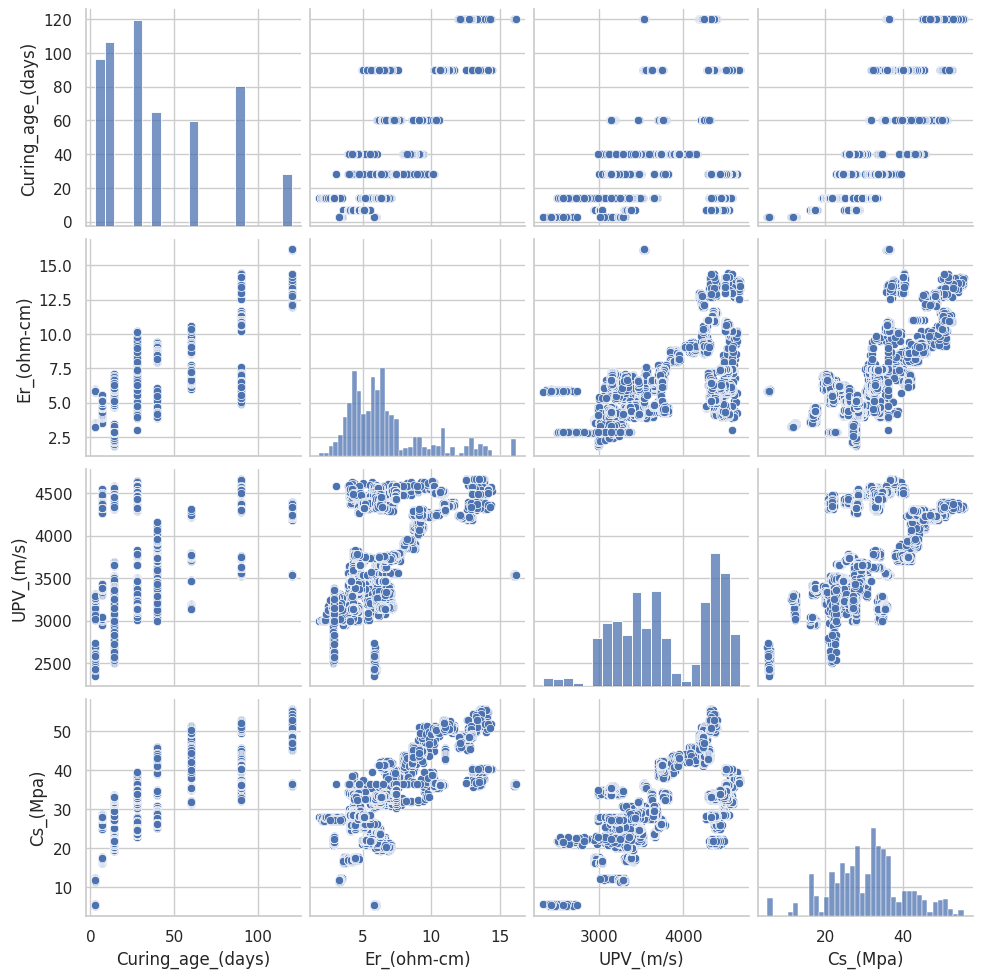

In [ ]:
# Plot pairwise plot
sns.pairplot(df[numercial_features_0])
plt.show()

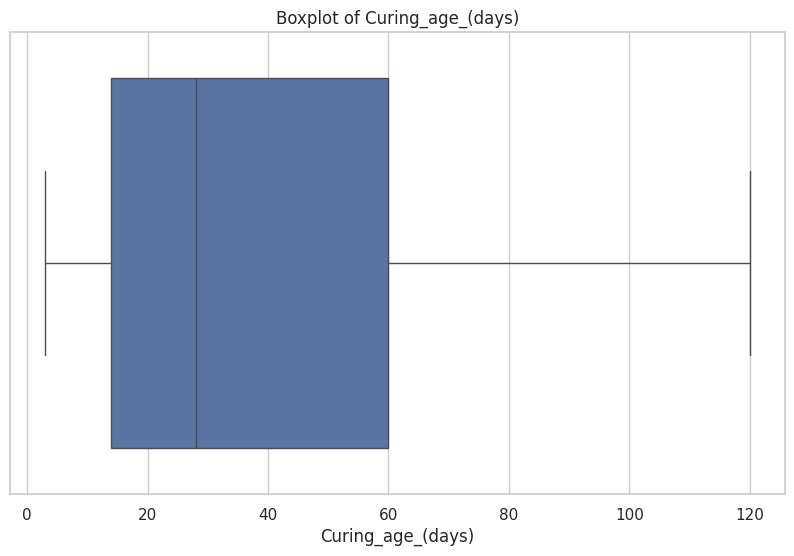

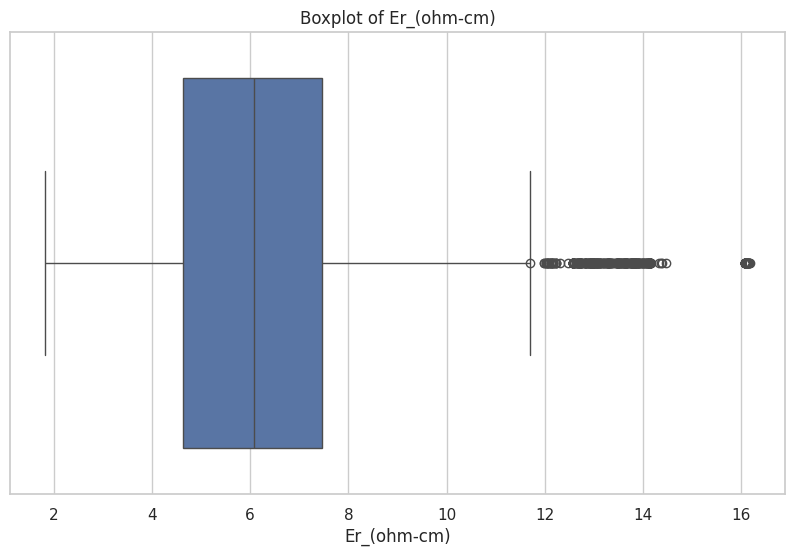

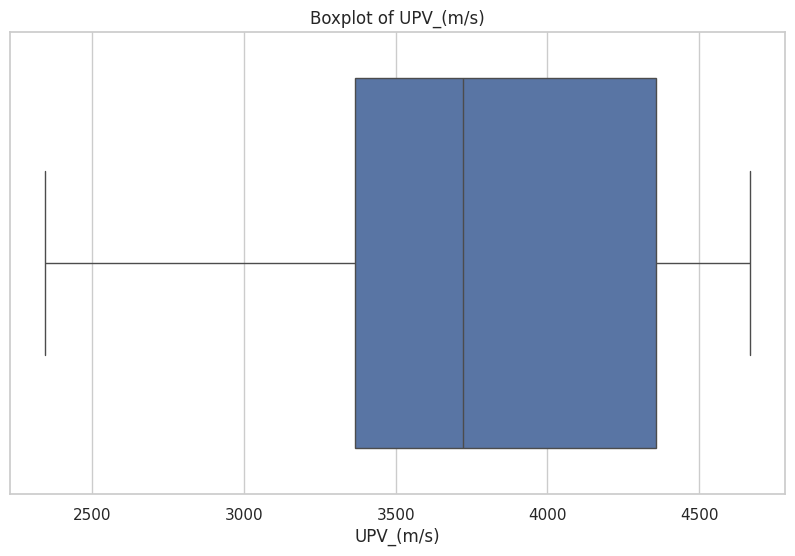

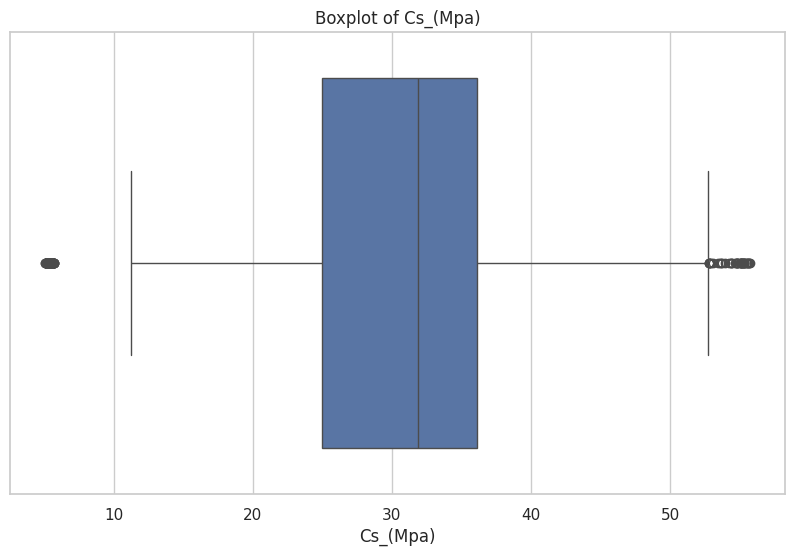

In [ ]:
for feature in numercial_features_0:
  plt.figure(figsize=(10,6))
  sns.boxplot(x=df[feature])
  plt.title(f'Boxplot of {feature}')
  plt.xlabel(feature)
  plt.show()

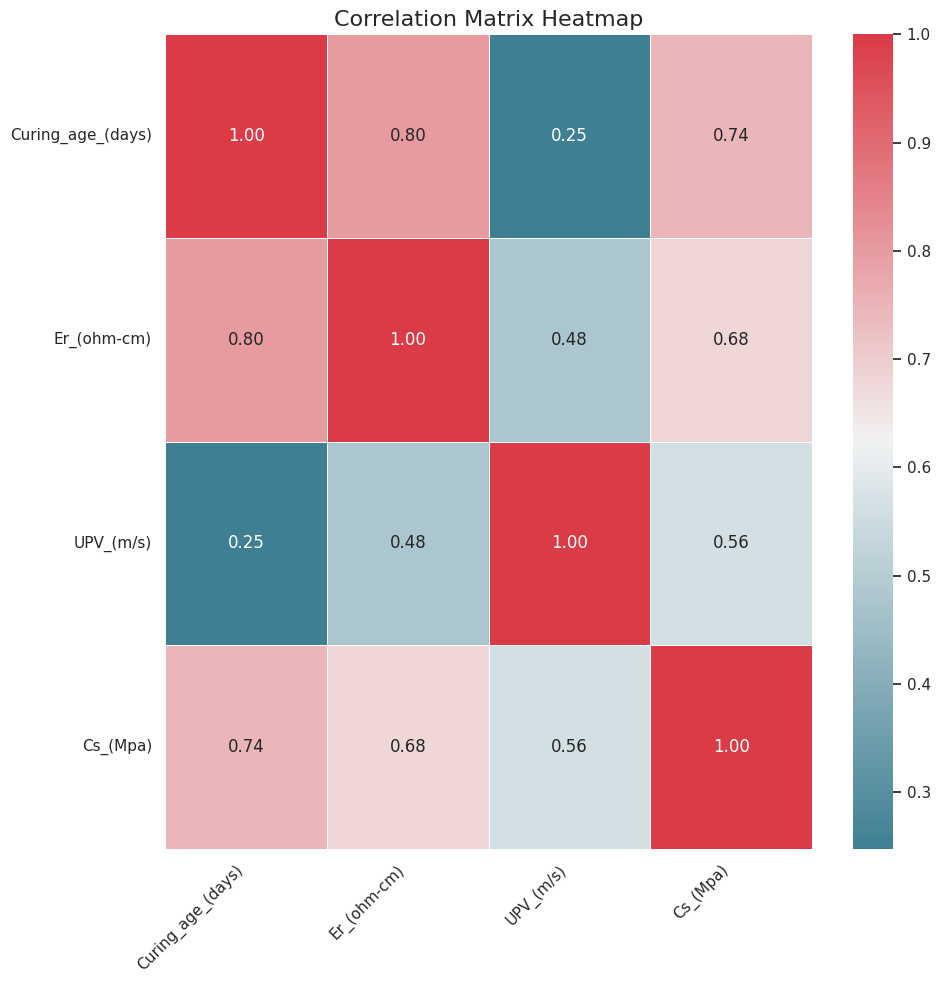

In [ ]:
corr_matrix = df[numercial_features_0].corr()
plt.figure(figsize=(10,10))
# Generate a custom diverging colormap
cmap = sns.diverging_palette(220, 10, as_cmap=True)

# Plot the heatmap
sns.heatmap(corr_matrix, annot=True, cmap=cmap, fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix Heatmap', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
# prompt: what to download df_2 as csv after saving

df_2.to_csv('df_2.csv', index=False)
from google.colab import files
files.download('df_2.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>